# Dynex SDK - Medium Native Gate Circuit Example

First we import the required packages:

In [1]:
import pennylane as qml
from dynex import DynexConfig, ComputeBackend, DynexCircuit

config = DynexConfig(compute_backend=ComputeBackend.QPU, qpu_model="apollo_rc1", use_notebook_output=True)

We define our circuit:

In [2]:
params = [0.3, 0.1]
wires = 3


def Medium(params):
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    qml.RX(params[0], wires=1)
    qml.CRZ(params[1], wires=[0, 1])
    qml.T(wires=1)
    qml.Toffoli(wires=[0, 1, 2])
    qml.SWAP(wires=[1, 2])
    return qml.state()

We draw the circuit:

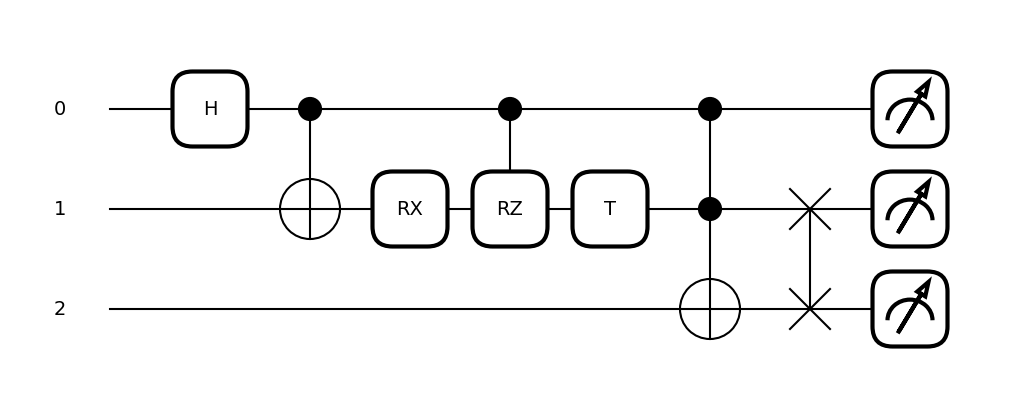

In [3]:
# draw circuit:
_ = qml.draw_mpl(Medium, style="black_white")(params)

We execute and measure the circuit on the Dynex platform:

In [4]:
# Execute the circuit on Dynex:
dynex_circuit = DynexCircuit(config=config)
measure = dynex_circuit.execute(Medium, params, wires, method="probs", num_reads=1,
                                integration_steps=10, shots=3)
print("Mesaure:", measure)

INFO: [DYNEX-APOLLO-RC1] Executing PennyLane quantum circuit
INFO: [DYNEX-APOLLO-RC1] Sampler initialised
INFO: [DYNEX-APOLLO-RC1] Apollo QPU chip: apollo_rc1
INFO: [DYNEX-APOLLO-RC1] Settings: num_reads=1, shots=3, annealing_time=10
INFO: [DYNEX-APOLLO-RC1] Submitting the job to Dynex.
INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=7408)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'cos_crz_0_1': 0.9987502603949663, 'cos_rx_1': 0.9887710779360422, 'cos_t_1': 0.7071067811865476, 'sin_crz_0_1': 0.04997916927067833, 'sin_rx_1': 0.14943813247359922, 'sin_t_1': 0.7071067811865475}
INFO: [DYNEX-APOLLO-RC1] model: {'offset': '0.0', 'q': '789c9556db4ec3300cfd95be0dd0a8726d137ea69a106393061ba31208c4bf9356a4b19338297b5a73b37d7c7cecef9bcddbc08771b83eed4e9b6d03bf6e1f1ad1b26d331d61c3615e6cee9ae9c4f5135c20f6dc75aefd7d3e1c5f76cfdec0fc7fdaf7db6218cffbfdf97404c7c472ec5e84671e5fcf237a2b2c407fddfaf50b9d736e91ef91b184dde91a67e11e4200058d300b1e2c5f30ee3cf2b371ef496219df98c20cc75ac595e0527742f6

Mesaure: [0.66666667 0.33333333 0.33333333]
